In [50]:
# Library yang digunakan
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from collections import Counter


## 💡 Load Data

In [51]:
#Load Dataser

version_5_5 = f"../data/review_genshin_5.5_clear.csv"
version_5_4 = f"../data/review_genshin_5.4_clear.csv"
version_5_3 = f"../data/review_genshin_5.3_clear.csv"
review_5_5 = pd.read_csv(version_5_5)
review_5_4 = pd.read_csv(version_5_4)
review_5_3 = pd.read_csv(version_5_3)

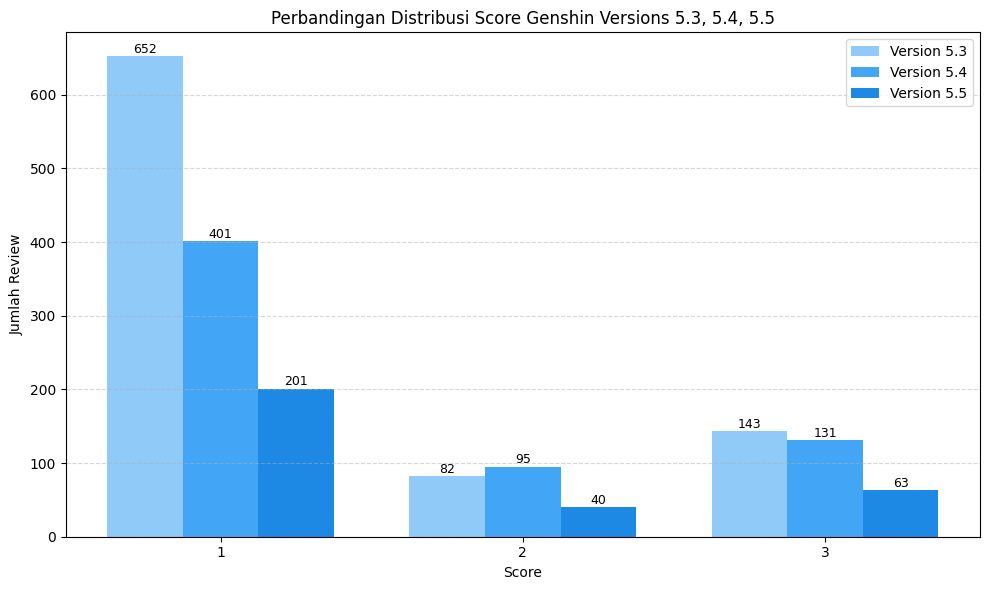

In [52]:
# Hitung jumlah score masing-masing versi
score_5_5 = review_5_5['Score'].value_counts().sort_index()
score_5_4 = review_5_4['Score'].value_counts().sort_index()
score_5_3 = review_5_3['Score'].value_counts().sort_index()

# Gabungkan semua score dari 1 sampai 5
all_scores = sorted(set(score_5_3.index) | set(score_5_4.index) | set(score_5_5.index))

# Reindex agar semua score ada
score_5_3 = score_5_3.reindex(all_scores, fill_value=0)
score_5_4 = score_5_4.reindex(all_scores, fill_value=0)
score_5_5 = score_5_5.reindex(all_scores, fill_value=0)

# Setup posisi x dan lebar bar
x = np.arange(len(all_scores))
width = 0.25

# Plot barplot
fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar(x - width, score_5_3.values, width, label='Version 5.3', color='#90CAF9')
bar2 = ax.bar(x, score_5_4.values, width, label='Version 5.4', color='#42A5F5')
bar3 = ax.bar(x + width, score_5_5.values, width, label='Version 5.5', color='#1E88E5')

# Tambahkan label jumlah di atas setiap bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(height),
                ha='center', va='bottom', fontsize=9)

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

# Konfigurasi tampilan
ax.set_xlabel('Score')
ax.set_ylabel('Jumlah Review')
ax.set_title('Perbandingan Distribusi Score Genshin Versions 5.3, 5.4, 5.5')
ax.set_xticks(x)
ax.set_xticklabels([str(score) for score in all_scores])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Barplot di atas menampilkan distribusi jumlah ulasan dengan skor negatif pada tiga versi terbaru dari game Genshin Impact, yaitu versi 5.3, 5.4, dan 5.5. Skor yang digunakan dalam grafik ini adalah skor 1, 2, dan 3 yang seluruhnya dikategorikan sebagai ulasan negatif. Setiap batang mewakili jumlah ulasan pada masing-masing skor di setiap versi.

Pada versi 5.3, jumlah ulasan negatif sangat tinggi, dengan skor 1 mencapai 652 review, menunjukkan tingkat ketidakpuasan yang sangat besar dari para pemain. Skor 2 dan 3 pun turut mencatat angka signifikan, masing-masing sebesar 82 dan 143 review. Ini mengindikasikan bahwa versi 5.3 menerima respon yang secara umum kurang baik dari komunitas pemain.

Memasuki versi 5.4, terjadi penurunan cukup besar pada jumlah ulasan dengan skor 1, yaitu menjadi 401 review. Meskipun angka ini masih tergolong tinggi, tren ini menunjukkan adanya perbaikan dari versi sebelumnya. Skor 2 justru mengalami sedikit peningkatan menjadi 95 review, sedangkan skor 3 menurun ke 131 review. Hal ini dapat diinterpretasikan bahwa sebagian pemain mulai merasa ada peningkatan, meskipun secara keseluruhan masih belum memuaskan.

Versi 5.5 menunjukkan perbaikan yang lebih signifikan. Jumlah ulasan negatif dengan skor 1 menurun drastis menjadi 201 review, menandakan bahwa tingkat kekecewaan pemain semakin berkurang. Skor 2 dan 3 juga ikut menurun masing-masing menjadi 40 dan 63 review, yang kemungkinan besar menunjukkan bahwa jumlah total ulasan negatif semakin menurun secara keseluruhan, baik dari sisi intensitas maupun jumlah pengguna yang menyampaikan keluhan.

Secara keseluruhan, grafik ini menggambarkan adanya tren penurunan jumlah ulasan negatif dari versi 5.3 ke versi 5.5. Hal ini mengindikasikan bahwa pengembang game kemungkinan telah melakukan berbagai perbaikan dan penyesuaian berdasarkan masukan pemain, yang berdampak positif terhadap persepsi pemain terhadap versi-versi terbaru yang dirilis.

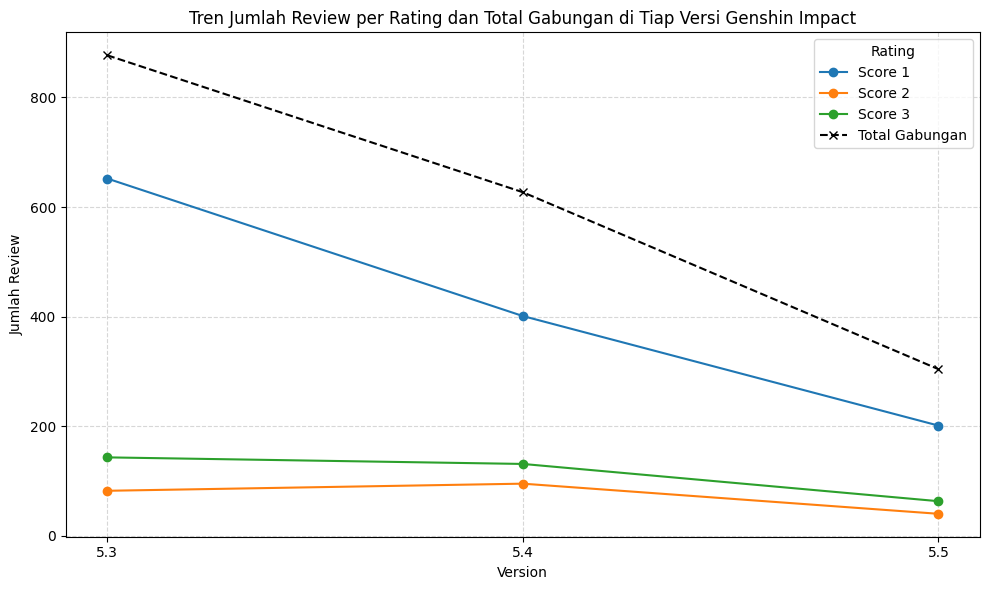

In [53]:
# Daftar file dan versi
version_files = {
    '5.3': '../data/review_genshin_5.3_clear.csv',
    '5.4': '../data/review_genshin_5.4_clear.csv',
    '5.5': '../data/review_genshin_5.5_clear.csv',
}

# Inisialisasi DataFrame kosong
all_data = pd.DataFrame()
total_data = pd.DataFrame()

# Loop semua versi
for version, file in version_files.items():
    df = pd.read_csv(file)
    score_count = df['Score'].value_counts().sort_index()
    score_count.name = version  # ganti nama series menjadi versi
    all_data = pd.concat([all_data, score_count], axis=1)
    
    # Total review gabungan per version (jumlah semua rating)
    total_review = df['Score'].count()
    total_data[version] = [total_review] * len(score_count)

# Pastikan index-nya (score) urut
all_data = all_data.fillna(0).astype(int).sort_index()
total_data = total_data.fillna(0)

# Transpose agar versi jadi index, lalu plot per score dan total gabungan
plt.figure(figsize=(10, 6))

# Plot per rating (Score 1, Score 2, dst.)
for score in all_data.index:
    plt.plot(all_data.columns, all_data.loc[score], marker='o', label=f'Score {score}')

# Plot total gabungan per versi
plt.plot(total_data.columns, total_data.iloc[0], marker='x', linestyle='--', label='Total Gabungan', color='black')

# Label dan tampilan
plt.title('Tren Jumlah Review per Rating dan Total Gabungan di Tiap Versi Genshin Impact')
plt.xlabel('Version')
plt.ylabel('Jumlah Review')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()

Untuk lineplot ini sendiri Garis biru—Score 1—mendominasi grafik. Di versi 5.3, jumlah review dengan score ini mencapai puncaknya di 652 ulasan. Ini adalah titik tertinggi ketidakpuasan. Namun, dari situ tampak jelas penurunan tajam: ke 401 di versi 5.4, dan kemudian tinggal 200 di versi 5.5. Ini adalah sinyal kuat bahwa perbaikan yang dilakukan pengembang mulai terasa oleh pemain, atau paling tidak, intensitas kemarahan mulai mereda.

Garis oranye (Score 2) dan hijau (Score 3) bergerak lebih datar, tapi tetap menunjukkan pola yang sama: penurunan perlahan, lalu merosot di versi 5.5. Score 2 sempat sedikit naik dari versi 5.3 ke 5.4, mungkin karena sebagian pemain merasa game-nya “sedikit lebih baik”, walau belum sepenuhnya puas. Tapi kemudian ikut menurun drastis ke versi 5.5. Score 3 yang mencerminkan kekecewaan ringan pun mengikuti jejak yang sama—dari sekitar 143 review di 5.3 menjadi hanya 63 di 5.5.

Yang paling menarik adalah garis hitam putus-putus: Total Gabungan Ulasan Negatif. Ini adalah akumulasi dari semua skor. Dan polanya jelas: menukik turun dari lebih dari 870 review di 5.3 menjadi hanya sekitar 300 di 5.5.

📉 Apa artinya?
Angka-angka ini bisa ditafsirkan dalam dua sisi:

Optimis: Upaya pengembang membuahkan hasil. Kritik di 5.3 dijadikan bahan perbaikan di versi selanjutnya, dan hasilnya: pemain jadi lebih puas, lebih sedikit yang komplain.

Pesimis: Pemain mulai kelelahan. Mereka sudah terlalu sering kecewa, dan akhirnya memilih untuk diam. Bukan karena mereka puas—tapi karena mereka sudah tidak berharap lagi.

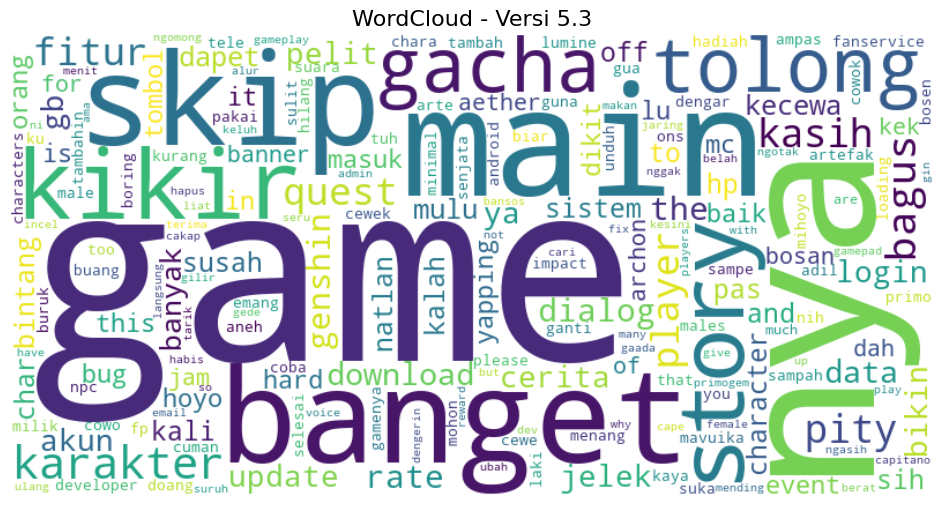

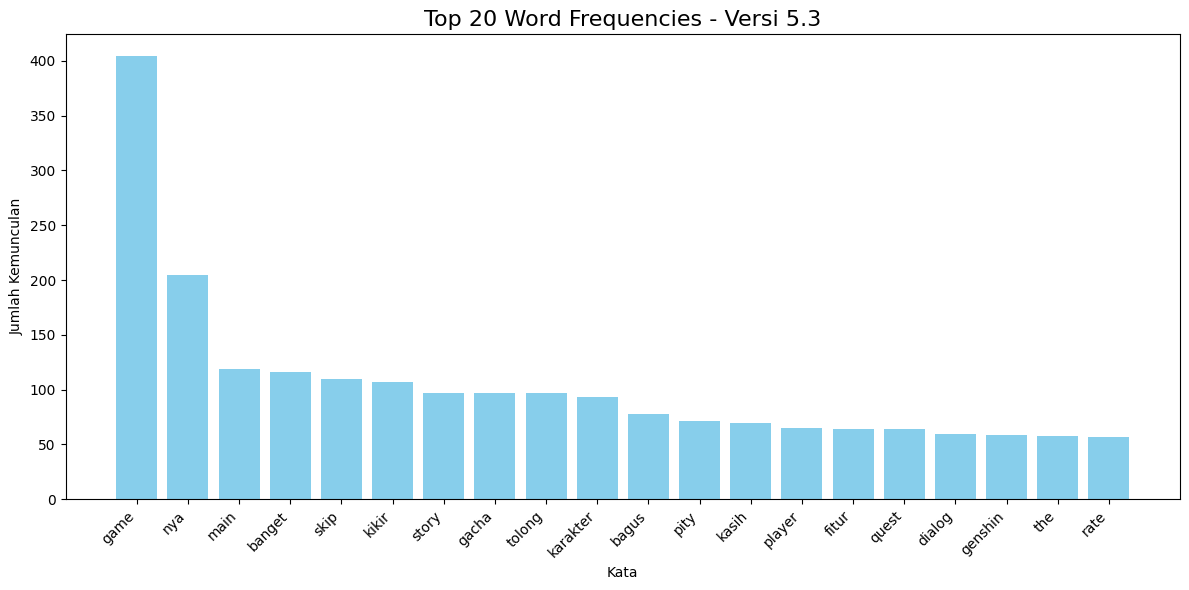

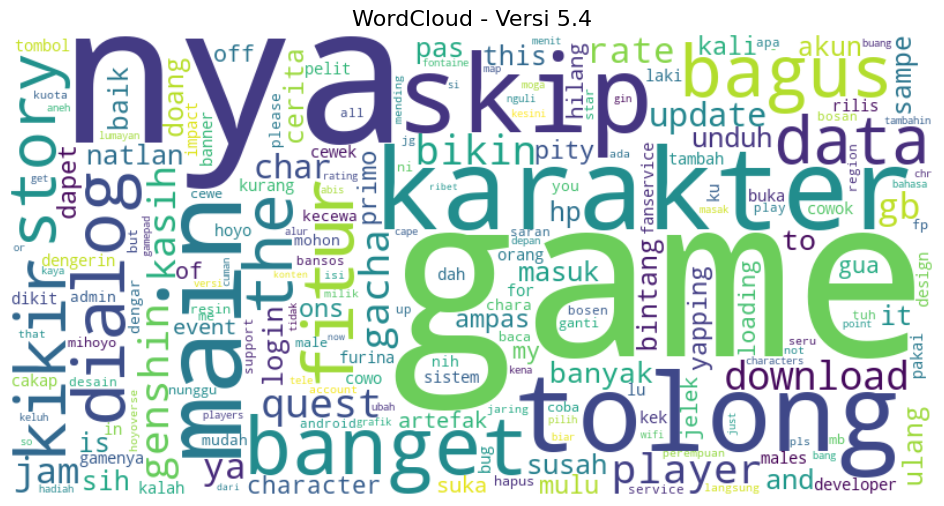

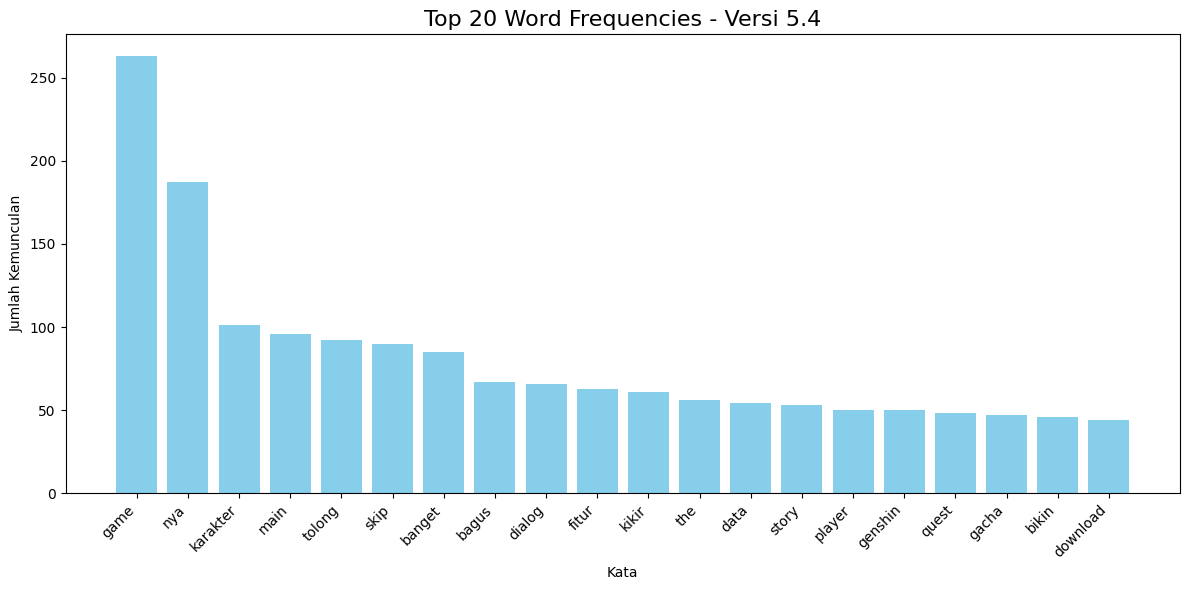

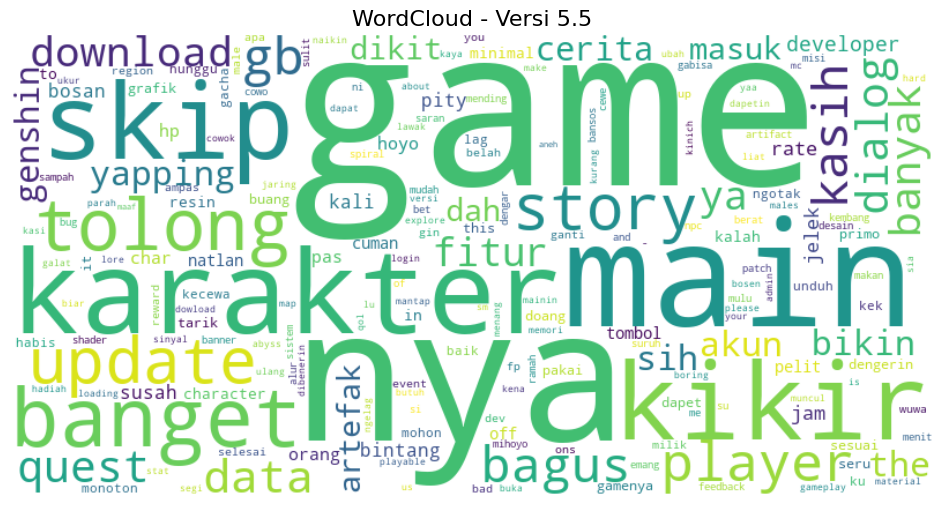

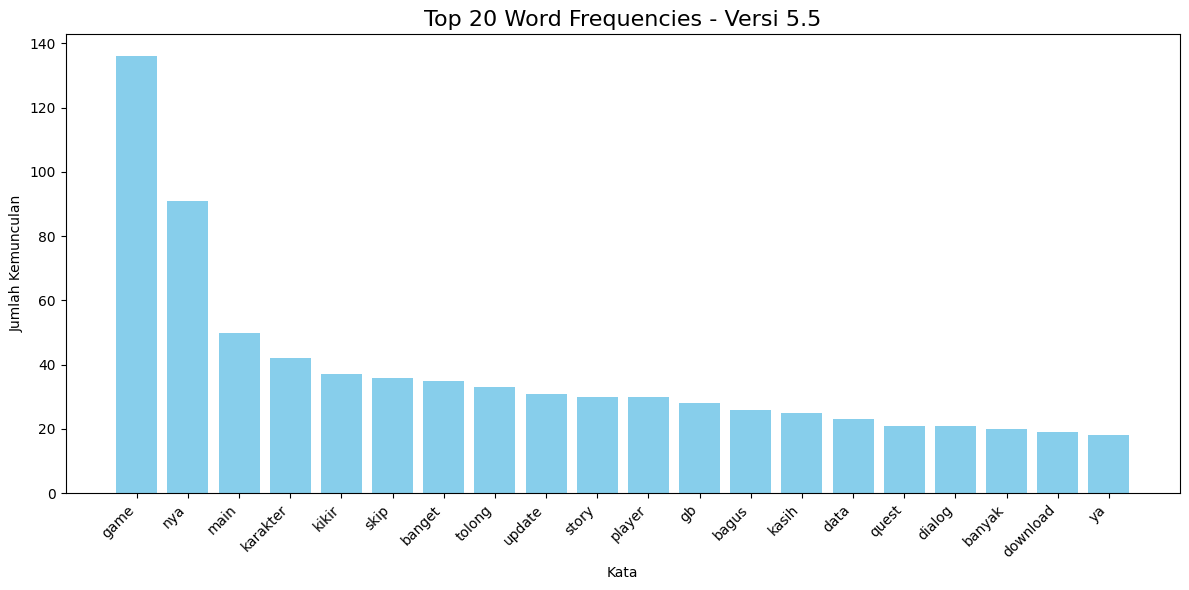

In [54]:
# Fungsi untuk membuat visualisasi WordCloud dan Bar Chart dari DataFrame
def visualize_word_frequency(df, judul=''):
    # Gabungkan semua teks dari kolom Content
    all_text = ' '.join(df['Content'].astype(str)).lower()

    # Tokenisasi
    words = all_text.split()

    # Hitung frekuensi kata
    word_counts = Counter(words)

    # Ambil 20 kata teratas
    most_common_words = word_counts.most_common(20)
    words_labels, words_values = zip(*most_common_words)

    # WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud - {judul}', fontsize=16)
    plt.show()

    # Bar Chart
    plt.figure(figsize=(12, 6))
    plt.bar(words_labels, words_values, color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 20 Word Frequencies - {judul}', fontsize=16)
    plt.xlabel('Kata')
    plt.ylabel('Jumlah Kemunculan')
    plt.tight_layout()
    plt.show()

# Load Dataset
version_5_5 = "../data/review_genshin_5.5_clear.csv"
version_5_4 = "../data/review_genshin_5.4_clear.csv"
version_5_3 = "../data/review_genshin_5.3_clear.csv"

review_5_5 = pd.read_csv(version_5_5)
review_5_4 = pd.read_csv(version_5_4)
review_5_3 = pd.read_csv(version_5_3)

# Visualisasi per versi
visualize_word_frequency(review_5_3, judul='Versi 5.3')
visualize_word_frequency(review_5_4, judul='Versi 5.4')
visualize_word_frequency(review_5_5, judul='Versi 5.5')

# 📊 Analisis Review Negatif Genshin Impact Versi 5.3 – 5.5

## 📉 Penurunan Jumlah Review Negatif

Dari grafik jumlah review per rating, terlihat:

- Jumlah review dengan skor 1 sangat mendominasi di semua versi dan menurun signifikan dari versi 5.3 ke 5.5:

- Dari sekitar 650 review di versi 5.3, menjadi hanya 200 di versi 5.5.

- Namun, penurunan ini bukanlah tanda perbaikan kualitas game. Sebaliknya, kemungkinan besar pengguna merasa lelah memberikan review negatif berulang, atau memilih tidak melibatkan diri lagi.
  - Pemain mulai **lelah mengeluh**
  - Atau memilih **tidak berinteraksi lagi**

- Total gabungan review (garis hitam) juga ikut menurun drastis, yang menunjukkan turunnya partisipasi pemain dalam memberikan feedback, kemungkinan akibat frustrasi yang berulang.
---


## ☁️ Isi Keluhan (WordCloud)

### 🔹 Versi 5.3
- Kata-kata besar: "game", "skip", "kikir", "main", "tolong", "fitur", "quest", "dialog".

- Kesan kuat adanya kekecewaan pada alur cerita, banyak pemain ingin fitur "skip dialog", menunjukkan narasi yang dianggap membosankan.

- Kata "kikir" (pelit) dan "gacha" muncul kuat, mengindikasikan frustrasi terhadap mekanisme monetisasi atau hadiah yang tidak memuaskan.

- Ada seruan seperti “tolong” dan “kasih”, mengisyaratkan permintaan kepada developer untuk memperbaiki atau lebih peduli terhadap pemain.

### 🔹 Versi 5.4
- Beberapa keluhan tetap kuat: "game", "karakter", "tolong", "skip", "dialog", "fitur".

- Kata “update” dan “player” juga terlihat, menandakan bahwa update tidak memenuhi harapan komunitas.

- Keluhan terhadap gacha dan kikir tetap ada, meskipun sedikit mereda secara visual.

- Tambahan kata seperti “data” dan “download” mungkin menandakan masalah teknis atau ukuran file yang membebani.

### 🔹 Versi 5.5
- Tidak ada perbedaan signifikan dalam jenis keluhan. Kata “kikir”, “quest”, “tolong”, “dialog”, “update” masih mendominasi.

- Kata “akun” mulai muncul lebih besar, mungkin mengindikasikan masalah login atau keamanan akun.

- Narasi “main”, “bosen”, dan “developer” juga kuat, menunjukkan ketidakpuasan umum terhadap pengalaman bermain dan manajemen pengembang.
---

## 🔠 Frekuensi Kata Tertinggi

### 📌 Versi 5.3
- Kata "skip" (110+), "kikir", "tolong", "pity", "gacha", dan “dialog” menduduki peringkat tinggi.
- Artinya: review negatif di versi ini banyak memuat kritik terhadap sistem hadiah, narasi panjang, dan kurangnya kepedulian developer.

### 📌 Versi 5.4
- "Skip", "kikir", "tolong", "dialog", dan “data” masih masuk dalam 20 besar.
- Ada penurunan jumlah tetapi tidak signifikan dalam isi keluhan, artinya ketidakpuasan tetap tinggi meski ekspresi sedikit berkurang.

### 📌 Versi 5.5
- Kata-kata seperti “update”, “dialog”, “bikin”, “akun”, “kikir”, “resin”, “bosan” menunjukkan kritik tetap menyasar ke aspek gameplay dan reward system.
- Kata "jelek" mulai muncul, memperjelas emosi negatif.
---



## 🎯 Kesimpulan
Meski jumlah review menurun, keluhan dari pemain Genshin Impact tetap konsisten dan mencerminkan frustrasi yang tidak ditangani. Review negatif tidak lagi hanya kuantitatif (jumlah), tetapi juga berkualitas secara ekspresif—melalui:

- Kata-kata seperti “kikir”, “skip”, “tolong”, dan “dialog” yang terus muncul di WordCloud dan Top Frequencies.

- Indikasi bahwa pemain merasa tidak didengar dan hanya mengulang keluhan yang sama dari versi ke versi.

- Penurunan review dapat menandakan kehilangan harapan, bukan perbaikan citra.

Ini bukan semata-mata soal review menurun, tapi soal respon pemain yang terus merasa diabaikan.
